In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


In [2]:
try:
    df = pd.read_excel('../Data/data.xlsx')
except Exception as e:
    print(f'Excel read failed ({e}), loading dataset.csv instead...')
    df = pd.read_csv('../Data/dataset.csv')
df.head()


,Timestamp,First name,Middle name,Last name,Full name,Email,Phone Number,Subject,Message,URL-honeypot
0,2020-08-19 20:00:33,EdwardNex,EdwardNexFR,EdwardNexFR,NaN,avitopost24@rambler.ru,89347784874,NaN,Здравствуйте! \n \nПредлагаем массовое размеще...,NaN
1,2020-08-24 14:18:50,JimmySiG,JimmySiGAI,JimmySiGAI,NaN,sdfwedfnerg@rambler.ru,87985992322,NaN,Представляем удаленный отдел продаж http://top...,http://krdsprt.club
2,2020-08-25 10:12:34,Mike,Mike AX,Mike AX,NaN,no-replysob@google.com,81498215433,NaN,Hеllо! \nIf you want to get ahead of your comp...,http://topgrf.club
3,2020-08-25 14:07:49,DennisHob,DennisHobJQ,DennisHobJQ,NaN,fwetsx5@rambler.ru,87677486522,NaN,Здравствуйте! \n \nВашей компании нужна свежая...,https://www.monkeydigital.co/Get-Guaranteed-Do...
4,2020-08-25 19:05:13,RobertDon,RobertDonGK,RobertDonGK,NaN,atrixxtrix@gmail.com,83718338333,NaN,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply...",http://krdsprt.club/base


In [3]:
# Labeling logic:
# - Submissions with filled honeypot URL = 1 (Bot)
# - Submissions with empty honeypot in the first 1906 rows = 0 (Human)
# - Submissions after row 1906 without honeypot = -1 (Unlabeled)
df['isBot'] = -1
df.loc[df['URL-honeypot'].astype(str).str.strip().ne('') & df['URL-honeypot'].notna(), 'isBot'] = 1
df.loc[df.index[:1906][df['URL-honeypot'].iloc[:1906].astype(str).str.strip().eq('') | df['URL-honeypot'].iloc[:1906].isna()], 'isBot'] = 0
print('Initial Label Distribution:')
print(df['isBot'].value_counts())
df.head()


Initial Label Distribution:
isBot
-1    3860
 1    1573
 0     333
Name: count, dtype: int64


,Timestamp,First name,Middle name,Last name,Full name,Email,Phone Number,Subject,Message,URL-honeypot,isBot
0,2020-08-19 20:00:33,EdwardNex,EdwardNexFR,EdwardNexFR,NaN,avitopost24@rambler.ru,89347784874,NaN,Здравствуйте! \n \nПредлагаем массовое размеще...,NaN,0
1,2020-08-24 14:18:50,JimmySiG,JimmySiGAI,JimmySiGAI,NaN,sdfwedfnerg@rambler.ru,87985992322,NaN,Представляем удаленный отдел продаж http://top...,http://krdsprt.club,1
2,2020-08-25 10:12:34,Mike,Mike AX,Mike AX,NaN,no-replysob@google.com,81498215433,NaN,Hеllо! \nIf you want to get ahead of your comp...,http://topgrf.club,1
3,2020-08-25 14:07:49,DennisHob,DennisHobJQ,DennisHobJQ,NaN,fwetsx5@rambler.ru,87677486522,NaN,Здравствуйте! \n \nВашей компании нужна свежая...,https://www.monkeydigital.co/Get-Guaranteed-Do...,1
4,2020-08-25 19:05:13,RobertDon,RobertDonGK,RobertDonGK,NaN,atrixxtrix@gmail.com,83718338333,NaN,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply...",http://krdsprt.club/base,1


In [4]:
df.isBot.value_counts() 

isBot
-1    3860
 1    1573
 0     333
Name: count, dtype: int64

In [5]:
df = df.drop(columns=['Full name'])
df

,Timestamp,First name,Middle name,Last name,Email,Phone Number,Subject,Message,URL-honeypot,isBot
0,2020-08-19 20:00:33,EdwardNex,EdwardNexFR,EdwardNexFR,avitopost24@rambler.ru,89347784874,NaN,Здравствуйте! \n \nПредлагаем массовое размеще...,NaN,0
1,2020-08-24 14:18:50,JimmySiG,JimmySiGAI,JimmySiGAI,sdfwedfnerg@rambler.ru,87985992322,NaN,Представляем удаленный отдел продаж http://top...,http://krdsprt.club,1
2,2020-08-25 10:12:34,Mike,Mike AX,Mike AX,no-replysob@google.com,81498215433,NaN,Hеllо! \nIf you want to get ahead of your comp...,http://topgrf.club,1
3,2020-08-25 14:07:49,DennisHob,DennisHobJQ,DennisHobJQ,fwetsx5@rambler.ru,87677486522,NaN,Здравствуйте! \n \nВашей компании нужна свежая...,https://www.monkeydigital.co/Get-Guaranteed-Do...,1
4,2020-08-25 19:05:13,RobertDon,RobertDonGK,RobertDonGK,atrixxtrix@gmail.com,83718338333,NaN,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply...",http://krdsprt.club/base,1
...,...,...,...,...,...,...,...,...,...,...
5761,NaT,NaN,NaN,NaN,NaN,NaN,NaN,Join the upcoming Secrets of Success movement ...,NaN,-1
5762,NaT,NaN,NaN,NaN,NaN,NaN,NaN,Is 'Secrets Of Success' For You...?\n\nPlease ...,NaN,-1
5763,NaT,NaN,NaN,NaN,NaN,NaN,NaN,FREE Training Based On This LOST Book Set Titl...,NaN,-1
5764,NaT,NaN,NaN,NaN,NaN,NaN,NaN,“Can One Book Really Be Worth $1.5 Million Dol...,NaN,-1


In [6]:
#handling missing values
df.fillna('', inplace=True)

,Timestamp,First name,Middle name,Last name,Email,Phone Number,Subject,Message,URL-honeypot,isBot
0,2020-08-19 20:00:33,EdwardNex,EdwardNexFR,EdwardNexFR,avitopost24@rambler.ru,89347784874,,Здравствуйте! \n \nПредлагаем массовое размеще...,,0
1,2020-08-24 14:18:50,JimmySiG,JimmySiGAI,JimmySiGAI,sdfwedfnerg@rambler.ru,87985992322,,Представляем удаленный отдел продаж http://top...,http://krdsprt.club,1
2,2020-08-25 10:12:34,Mike,Mike AX,Mike AX,no-replysob@google.com,81498215433,,Hеllо! \nIf you want to get ahead of your comp...,http://topgrf.club,1
3,2020-08-25 14:07:49,DennisHob,DennisHobJQ,DennisHobJQ,fwetsx5@rambler.ru,87677486522,,Здравствуйте! \n \nВашей компании нужна свежая...,https://www.monkeydigital.co/Get-Guaranteed-Do...,1
4,2020-08-25 19:05:13,RobertDon,RobertDonGK,RobertDonGK,atrixxtrix@gmail.com,83718338333,,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply...",http://krdsprt.club/base,1
...,...,...,...,...,...,...,...,...,...,...
5761,NaT,,,,,,,Join the upcoming Secrets of Success movement ...,,-1
5762,NaT,,,,,,,Is 'Secrets Of Success' For You...?\n\nPlease ...,,-1
5763,NaT,,,,,,,FREE Training Based On This LOST Book Set Titl...,,-1
5764,NaT,,,,,,,“Can One Book Really Be Worth $1.5 Million Dol...,,-1


In [7]:
#Feature engineering
#raw data ke numbers e


In [8]:
# Text feature extraction using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
df['Message'] = df['Message'].fillna('')
df_labeled = df.iloc[:1906].copy()
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf.fit(df_labeled['Message'])
X_text = tfidf.transform(df['Message'])
X_text_labeled = tfidf.transform(df_labeled['Message'])


In [9]:
#Text feature
#from sklearn.feature_extraction.text import TfidfVectorizer
#TF-IDF use korbo
#tfidf = TfidfVectorizer(max_features=500)
#X_text = tfidf.fit_transform(df['Message'])


In [10]:
#checking the matrxi
X_text.shape
x_normal_array= X_text.toarray()
print(x_normal_array)

[[0.         0.         0.19146328 ... 0.20417979 0.80410638 0.42247945]
 [0.         0.         0.         ... 0.         0.65312467 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [11]:
#convertin into a dataframe
feature_name = tfidf.get_feature_names_out()
df_tfidf=pd.DataFrame(X_text.toarray(),columns=feature_name)


In [12]:
# Email features
df['Email'] = df['Email'].fillna('')
df['Email_len'] = df['Email'].apply(len)
df['has_numbers_email'] = df['Email'].str.contains(r'\d').astype(int)
df['is_free_domain'] = df['Email'].str.contains('gmail|yahoo|hotmail').astype(int)


In [13]:
# Phone feature
df['Phone Number'] = df['Phone Number'].fillna('')
df['phone_len'] = df['Phone Number'].astype(str).apply(len)


In [14]:
# Message features
df['Message'] = df['Message'].fillna('')
df['msg_len'] = df['Message'].apply(len)
df['num_links'] = df['Message'].str.count('http')
df['num_special_chars'] = df['Message'].str.count(r'[!@#$%^&*()]')


In [15]:
#time feature
df = df.drop(columns=['Timestamp', 'hour'], errors='ignore')


In [16]:
#step 4 , we will combine features
df_labeled = df.iloc[:1906].copy()
X_numeric =  df[['Email_len','has_numbers_email','is_free_domain','phone_len',
   'msg_len','num_links','num_special_chars']]
X_numeric_labeled = df_labeled[['Email_len','has_numbers_email','is_free_domain','phone_len',
   'msg_len','num_links','num_special_chars']]


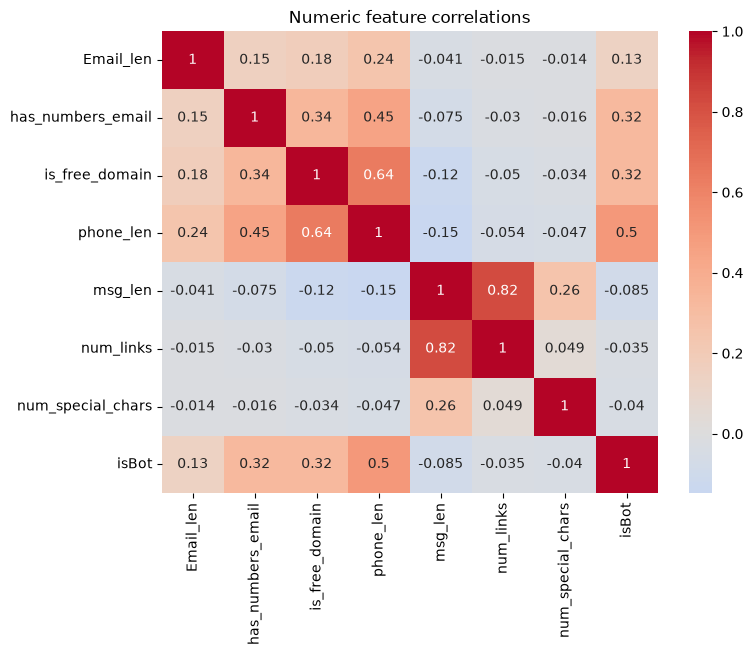

In [17]:

# Correlation heatmap for numeric features + label
num_cols = ['Email_len','has_numbers_email','is_free_domain','phone_len',
                'msg_len','num_links','num_special_chars','isBot']
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Numeric feature correlations')
plt.show()

In [18]:
#Combine text + numeric features with scipy
from scipy.sparse import hstack
X = hstack([X_text,X_numeric])
X_labeled = hstack([X_text_labeled,X_numeric_labeled])
y = df['isBot']
y_labeled = df_labeled['isBot']


Text(0.5, 1.0, 'Label distribution')

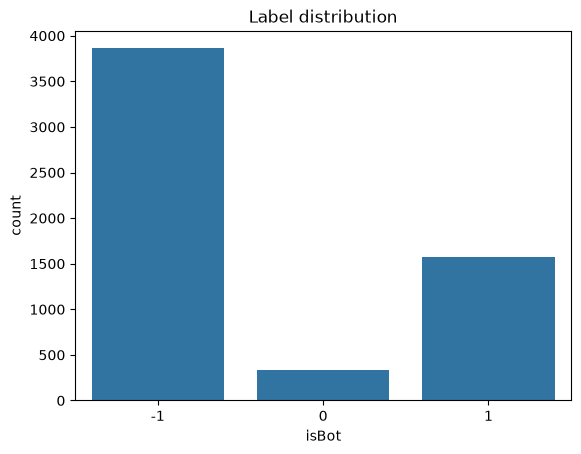

In [19]:
#EDA
sns.countplot(x='isBot', data=df); plt.title('Label distribution')

In [20]:
#error in model training because missing values in X(NaN)
#Random forest cant train on missing data


In [21]:
#dataset final view
#df.head()
#df.to_csv("ml_dataset.csv",index=False)

# Now ill take 1906 data because oh honeypot url is missing after that

In [22]:
# Label verification
print('Verified label distribution (isBot):')
print(df['isBot'].value_counts())


Verified label distribution (isBot):
isBot
-1    3860
 1    1573
 0     333
Name: count, dtype: int64


In [23]:
# Detailed counts of labels
print(f'Confirmed Humans (0): {(df["isBot"] == 0).sum()}')
print(f'Confirmed Bots (1):   {(df["isBot"] == 1).sum()}')
print(f'Unlabeled rows (-1):   {(df["isBot"] == -1).sum()}')


Confirmed Humans (0): 333
Confirmed Bots (1):   1573
Unlabeled rows (-1):   3860


Text(0.5, 1.0, 'Label distribution')

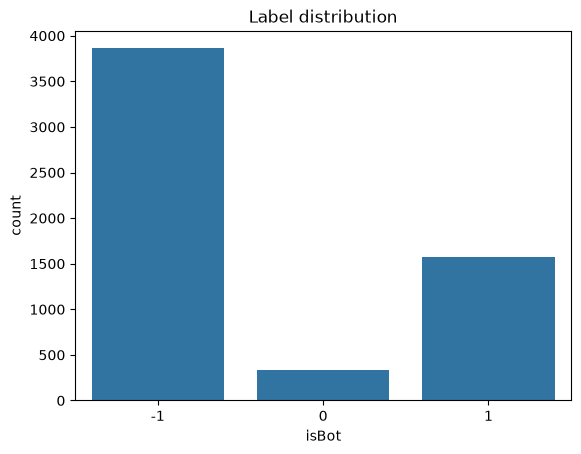

In [24]:
sns.countplot(x='isBot', data=df); plt.title('Label distribution')

In [25]:
df = df.drop(columns=['First name', 'Middle name', 'Last name', 'Subject'], inplace=False)
#df.to_csv("dataset.csv", index=False)
df

,Email,Phone Number,Message,URL-honeypot,isBot,Email_len,has_numbers_email,is_free_domain,phone_len,msg_len,num_links,num_special_chars
0,avitopost24@rambler.ru,89347784874,Здравствуйте! \n \nПредлагаем массовое размеще...,,0,22,1,0,11,1043,2,9
1,sdfwedfnerg@rambler.ru,87985992322,Представляем удаленный отдел продаж http://top...,http://krdsprt.club,1,22,0,0,11,605,3,1
2,no-replysob@google.com,81498215433,Hеllо! \nIf you want to get ahead of your comp...,http://topgrf.club,1,22,0,0,11,398,1,2
3,fwetsx5@rambler.ru,87677486522,Здравствуйте! \n \nВашей компании нужна свежая...,https://www.monkeydigital.co/Get-Guaranteed-Do...,1,18,1,0,11,974,3,11
4,atrixxtrix@gmail.com,83718338333,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply...",http://krdsprt.club/base,1,20,0,1,11,957,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
5761,,,Join the upcoming Secrets of Success movement ...,,-1,0,0,0,0,614,1,6
5762,,,Is 'Secrets Of Success' For You...?\n\nPlease ...,,-1,0,0,0,0,718,1,9
5763,,,FREE Training Based On This LOST Book Set Titl...,,-1,0,0,0,0,391,1,6
5764,,,“Can One Book Really Be Worth $1.5 Million Dol...,,-1,0,0,0,0,243,1,2


## Unsupervised Pattern Discovery with K-Means Clustering
Here we apply **K-Means clustering** on standardized numeric features combined with TF-IDF text features to discover latent patterns in both labeled and unlabeled records.

In [26]:
# K-Means Clustering to discover latent patterns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

# 1. Standardize numeric features
scaler = StandardScaler()
num_feature_cols = ['Email_len', 'has_numbers_email', 'is_free_domain', 'phone_len', 'msg_len', 'num_links', 'num_special_chars']
X_num_scaled = scaler.fit_transform(df[num_feature_cols].fillna(0))

# 2. Combine with TF-IDF text features
X_clustering = hstack([X_text, X_num_scaled]).tocsr()

# 3. Fit K-Means with K=3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clustering)

# 4. Cross-tabulation: Clusters vs isBot labels
label_map = {-1: "Unlabeled (-1)", 0: "Human (0)", 1: "Bot (1)"}
cluster_crosstab = pd.crosstab(df['cluster'], df['isBot'].map(label_map), margins=True)
print("=== Cluster vs. Label Distribution ===")
display(cluster_crosstab)

# 5. Profile each cluster with numeric feature means
cluster_profile = df.groupby('cluster')[num_feature_cols].mean().round(2)
print("\n=== Cluster Mean Profiles (Numeric Features) ===")
display(cluster_profile)


=== Cluster vs. Label Distribution ===


isBot,Bot (1),Human (0),Unlabeled (-1),All
cluster,,,,
0,1087,273,1024,2384
1,485,60,2826,3371
2,1,0,10,11
All,1573,333,3860,5766



=== Cluster Mean Profiles (Numeric Features) ===


,Email_len,has_numbers_email,is_free_domain,phone_len,msg_len,num_links,num_special_chars
cluster,,,,,,,
0,23.68,0.49,0.83,11.30,257.62,0.98,2.09
1,4.54,0.00,0.00,1.83,647.28,2.24,8.75
2,9.09,0.00,0.00,2.18,30131.82,635.64,56.55


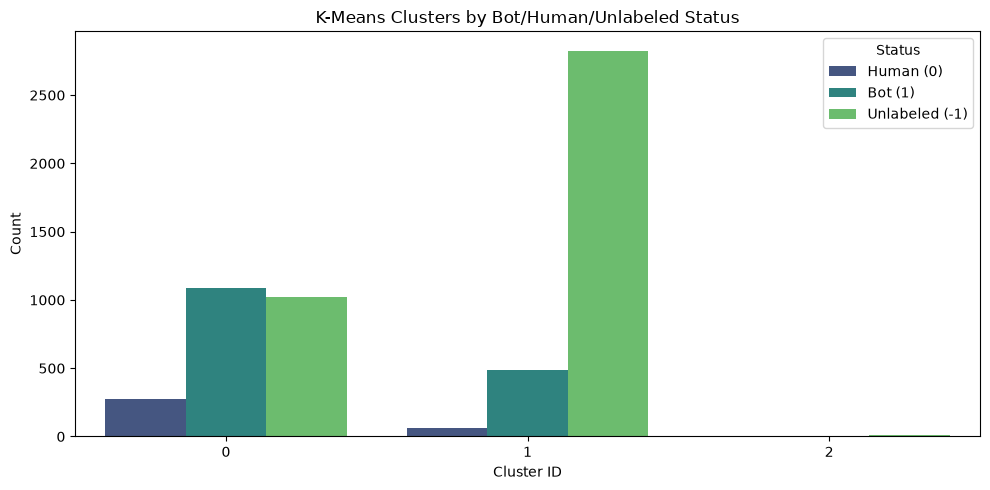

In [27]:
# Visualize Cluster distribution by isBot status
plt.figure(figsize=(10, 5))
label_map = {-1: 'Unlabeled (-1)', 0: 'Human (0)', 1: 'Bot (1)'}
sns.countplot(data=df, x='cluster', hue=df['isBot'].map(label_map), palette='viridis')
plt.title('K-Means Clusters by Bot/Human/Unlabeled Status')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


In [28]:
#XGboost+self
from xgboost import XGBClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

y_semi = df['isBot']

# Tune XGBoost on the labeled subset before self-training
X_xgb = X_labeled.tocsr()
y_xgb = y_labeled

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.3,
    random_state=42,
    stratify=y_xgb,
)

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 3],
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, tree_method='hist'),
    param_grid=xgb_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

xgb_grid_search.fit(X_train_xgb, y_train_xgb)

print("Best XGBoost Parameters:", xgb_grid_search.best_params_)
print("Best XGBoost CV F1 Score:", xgb_grid_search.best_score_)

xgb_base = xgb_grid_search.best_estimator_


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost CV F1 Score: 0.9297614888397813


In [29]:
self_training_model = SelfTrainingClassifier(xgb_base,threshold=0.8)
self_training_model.fit(X,y_semi)

,"estimator estimator: estimator objectAn estimator object implementing `fit` and `predict_proba`.Invoking the `fit` method will fit a clone of the passed estimator,which will be stored in the `estimator_` attribute... versionadded:: 1.6 `estimator` was added to replace `base_estimator`.","XGBClassifier...ree=None, ...)"
,"threshold threshold: float, default=0.75The decision threshold for use with `criterion='threshold'`.Should be in [0, 1). When using the `'threshold'` criterion, a:ref:`well calibrated classifier <calibration>` should be used.",0.8
,"criterion criterion: {'threshold', 'k_best'}, default='threshold'The selection criterion used to select which labels to add to thetraining set. If `'threshold'`, pseudo-labels with predictionprobabilities above `threshold` are added to the dataset. If `'k_best'`,the `k_best` pseudo-labels with highest prediction probabilities areadded to the dataset. When using the 'threshold' criterion, a:ref:`well calibrated classifier <calibration>` should be used.",'threshold'
,"k_best k_best: int, default=10The amount of samples to add in each iteration. Only used when`criterion='k_best'`.",10
,"max_iter max_iter: int or None, default=10Maximum number of iterations allowed. Should be greater than or equalto 0. If it is `None`, the classifier will continue to predict labelsuntil no new pseudo-labels are added, or all unlabeled samples havebeen labeled.",10
,"verbose verbose: bool, default=FalseEnable verbose output.",False
Name,Type,Value
"classes_ classes_: ndarray or list of ndarray of shape (n_classes,)Class labels for each output. (Taken from the trained`estimator_`).","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimator objectThe fitted estimator.,XGBClassifier,"XGBClassifier...ree=None, ...)"
"labeled_iter_ labeled_iter_: ndarray of shape (n_samples,)The iteration in which each sample was labeled. When a sample hasiteration 0, the sample was already labeled in the original dataset.When a sample has iteration -1, the sample was not labeled in anyiteration.","ndarray[int64](5766,)","[0,0,0,...,2,1,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,107


In [30]:
from sklearn.metrics import classification_report,accuracy_score
labeled_mask = y_semi!= -1

# Convert X to CSR format to allow indexing
X = X.tocsr()

X_labeled = X[labeled_mask.to_numpy()]
y_true = y_semi[labeled_mask]

#make predicts using the trained self model
y_pred = self_training_model.predict(X_labeled)

# This is an in-sample diagnostic, not a holdout score.
print("Training-set Accuracy:", accuracy_score(y_true, y_pred))
print("\nTraining-set Classification Report:\n", classification_report(y_true, y_pred))


Training-set Accuracy: 0.887722980062959

Training-set Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.46      0.59       333
           1       0.90      0.98      0.93      1573

    accuracy                           0.89      1906
   macro avg       0.86      0.72      0.76      1906
weighted avg       0.88      0.89      0.87      1906



In [31]:
# Holdout test for self-training (real test set on labeled data)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

X_csr = X.tocsr()
labeled_mask = y_semi != -1
labeled_idx = np.where(labeled_mask)[0]

train_idx, test_idx = train_test_split(
    labeled_idx,
    test_size=0.3,
    random_state=42,
    stratify=y_semi[labeled_mask],
 )

# Hide labels for the holdout part during training
y_semi_train = y_semi.copy()
y_semi_train.iloc[test_idx] = -1

self_training_model_holdout = SelfTrainingClassifier(xgb_base, threshold=0.8)
self_training_model_holdout.fit(X_csr, y_semi_train)

X_test_holdout = X_csr[test_idx]
y_test_holdout = y_semi.iloc[test_idx]
y_pred_holdout = self_training_model_holdout.predict(X_test_holdout)

self_training_holdout_accuracy = accuracy_score(y_test_holdout, y_pred_holdout)
self_training_holdout_weighted_f1 = f1_score(y_test_holdout, y_pred_holdout, average="weighted")

print("Holdout Accuracy:", self_training_holdout_accuracy)
print("\nHoldout Classification Report:\n", classification_report(y_test_holdout, y_pred_holdout))

Holdout Accuracy: 0.8898601398601399

Holdout Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.47      0.60       100
           1       0.90      0.98      0.94       472

    accuracy                           0.89       572
   macro avg       0.86      0.72      0.77       572
weighted avg       0.88      0.89      0.88       572



In [32]:
# Logistic Regression with holdout test
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Train on labeled data with holdout
X_csr = X.tocsr()
labeled_mask = y_semi != -1
labeled_idx = np.where(labeled_mask)[0]

train_idx, test_idx = train_test_split(
    labeled_idx,
    test_size=0.3,
    random_state=42,
    stratify=y_semi[labeled_mask],
)

X_train_lr = X_csr[train_idx]
X_test_lr = X_csr[test_idx]
y_train_lr = y_semi.iloc[train_idx]
y_test_lr = y_semi.iloc[test_idx]

lr_param_grid = {
    "C": [0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"],
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

lr_grid_search.fit(X_train_lr, y_train_lr)

print("Best Logistic Regression Parameters:", lr_grid_search.best_params_)
print("Best Logistic Regression CV F1 Score:", lr_grid_search.best_score_)

lr_model = lr_grid_search.best_estimator_

# Evaluate logistic regression
y_pred_lr = lr_model.predict(X_test_lr)
lr_holdout_accuracy = accuracy_score(y_test_lr, y_pred_lr)
lr_holdout_weighted_f1 = f1_score(y_test_lr, y_pred_lr, average="weighted")

print("Logistic Regression Holdout Accuracy:", lr_holdout_accuracy)
print("\nLogistic Regression Holdout Classification Report:\n", classification_report(y_test_lr, y_pred_lr))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Logistic Regression Parameters: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best Logistic Regression CV F1 Score: 0.9287258878292789
Logistic Regression Holdout Accuracy: 0.8811188811188811

Logistic Regression Holdout Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.50      0.60       100
           1       0.90      0.96      0.93       472

    accuracy                           0.88       572
   macro avg       0.82      0.73      0.76       572
weighted avg       0.87      0.88      0.87       572



In [33]:
# Final Results Summary
from sklearn.metrics import accuracy_score, f1_score

best_model_name = max(
    [
        ("XGBoost", self_training_holdout_weighted_f1),
        ("Logistic Regression", lr_holdout_weighted_f1),
    ],
    key=lambda item: item[1],
)

results = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            "Best Params": xgb_grid_search.best_params_,
            "CV F1": xgb_grid_search.best_score_,
            "Holdout Accuracy": self_training_holdout_accuracy,
            "Holdout Weighted F1": self_training_holdout_weighted_f1,
        },
        {
            "Model": "Logistic Regression",
            "Best Params": lr_grid_search.best_params_,
            "CV F1": lr_grid_search.best_score_,
            "Holdout Accuracy": lr_holdout_accuracy,
            "Holdout Weighted F1": lr_holdout_weighted_f1,
        },
    ]
)

print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(results.to_string(index=False))
print("\nBest Overall Model:")
print(f"   {best_model_name[0]} with holdout weighted F1 {best_model_name[1]:.4f}")
print("="*70)

FINAL RESULTS SUMMARY
              Model                                                                                                                    Best Params    CV F1  Holdout Accuracy  Holdout Weighted F1
            XGBoost {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8} 0.929761          0.889860             0.877176
Logistic Regression                                                         {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'} 0.928726          0.881119             0.871746

Best Overall Model:
   XGBoost with holdout weighted F1 0.8772
